### Model Monitoring & Validation

#### Objective

Evaluate the stability, calibration, discriminatory power, and monitoring characteristics of the developed credit scorecard.

This notebook simulates post-development model surveillance activities commonly performed within portfolio risk management teams to ensure model robustness, stability, and ongoing business relevance.

### Load Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
scorecard_output = pd.read_csv("..\Dataset\Processed\scorecard_output.csv")

In [3]:
scorecard_output.describe()

,TARGET,PD,score
count,87493.000000,87493.000000,87493.000000
mean,0.030094,0.030151,595.871521
std,0.170847,0.027690,23.165931
min,0.000000,0.001332,509.136987
25%,0.000000,0.013545,580.415296
50%,0.000000,0.023506,594.652858
75%,0.000000,0.037933,610.850385
max,1.000000,0.318006,678.138020


In [4]:
scorecard_output['grade'].value_counts()

grade
C    29562
D    21408
B    19809
A    16714
Name: count, dtype: int64

In [5]:
scorecard_output['recommendation'].value_counts()

recommendation
REVIEW     49371
DECLINE    21408
APPROVE    16714
Name: count, dtype: int64

### Calibration Analysis

In [6]:
scorecard_output['pd_bucket'] = pd.qcut(
    scorecard_output['PD'],
    q=10
)

In [7]:
calibration = (

    scorecard_output

    .groupby('pd_bucket')

    .agg(

        avg_predicted_pd=('PD','mean'),

        observed_bad_rate=('TARGET','mean'),

        accounts=('TARGET','count')

    )

    .reset_index()

)

calibration

,pd_bucket,avg_predicted_pd,observed_bad_rate,accounts
0,"(0.00033, 0.00828]",0.006096,0.009593,8861
1,"(0.00828, 0.0106]",0.009356,0.008271,8705
2,"(0.0106, 0.0154]",0.013521,0.014480,8909
3,"(0.0154, 0.0183]",0.017025,0.014891,8730
4,"(0.0183, 0.0235]",0.021354,0.023400,9017
5,"(0.0235, 0.0291]",0.026265,0.026821,8277
6,"(0.0291, 0.0336]",0.031691,0.029930,9656
7,"(0.0336, 0.0428]",0.038911,0.038402,8411
8,"(0.0428, 0.0564]",0.048327,0.045738,8177
9,"(0.0564, 0.318]",0.090867,0.091200,8750


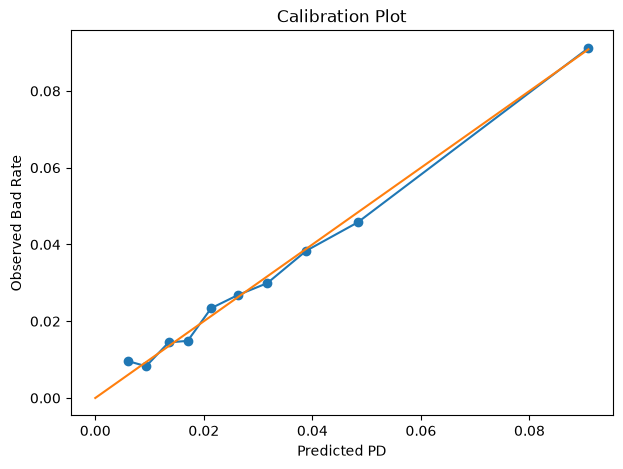

In [8]:
plt.figure(figsize=(7,5))

plt.plot(

    calibration['avg_predicted_pd'],

    calibration['observed_bad_rate'],

    marker='o'

)

plt.plot(
    [0, calibration['avg_predicted_pd'].max()],
    [0, calibration['avg_predicted_pd'].max()]
)

plt.xlabel("Predicted PD")

plt.ylabel("Observed Bad Rate")

plt.title("Calibration Plot")

plt.show()

### Lift Table

In [9]:
lift_table = (

    scorecard_output

    .groupby('risk_band')

    .agg(

        accounts=('TARGET','count'),

        bad_rate=('TARGET','mean')

    )

)

lift_table

,accounts,bad_rate
risk_band,,
RB1,8750,0.091200
RB10,7794,0.010393
RB2,8795,0.045139
RB3,9733,0.036577
RB4,7752,0.030186
RB5,9466,0.027361
RB6,8640,0.021296
RB7,8300,0.015060
RB8,8768,0.014484


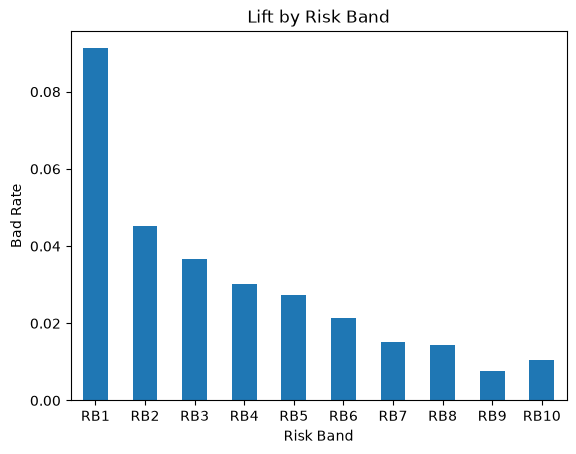

In [10]:
import matplotlib.pyplot as plt

order = [f"RB{i}" for i in range(1, 11)]

lift_table = lift_table.reindex(order)

lift_table['bad_rate'].plot(kind='bar')

plt.title("Lift by Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Bad Rate")
plt.xticks(rotation=0)

plt.show()

### Portfolio Segmentation

In [11]:
portfolio_seg = (

    scorecard_output

    .groupby('grade')

    .agg(

        customers=('TARGET','count'),

        bad_rate=('TARGET','mean')

    )

)

portfolio_seg

,customers,bad_rate
grade,,
A,16714,0.008556
B,19809,0.015347
C,29562,0.028144
D,21408,0.063247


### Approval Strategy Impact

In [12]:
approval_analysis = (

    scorecard_output

    .groupby('recommendation')

    .agg(

        customers=('TARGET','count'),

        bad_rate=('TARGET','mean')

    )

)

approval_analysis

,customers,bad_rate
recommendation,,
APPROVE,16714,0.008556
DECLINE,21408,0.063247
REVIEW,49371,0.023009


### PSI

In [13]:
import pickle

with open("../Models/final_logit.pkl", "rb") as f:
    final_model = pickle.load(f)

with open("../Models/final_features.pkl", "rb") as f:
    final_features = pickle.load(f)

In [14]:
train_model = pd.read_csv(
    "../Dataset/processed/train_model.csv"
)

test_model = pd.read_csv(
    "../Dataset/processed/test_model.csv"
)

print(train_model.shape)
print(test_model.shape)

(204150, 8)
(87493, 8)


In [16]:
train_model = train_model.drop(columns=["num_prev_apps_woe"])
test_model = test_model.drop(columns=["num_prev_apps_woe"])
print(train_model.shape)
print(test_model.shape)

(204150, 7)
(87493, 7)


In [17]:
# Recreating train PD predictions
import statsmodels.api as sm

X_train = sm.add_constant(
    train_model[final_features]
)

train_model['PD'] = final_model.predict(
    X_train
)

In [18]:
# Recreating test PD predictions
X_test = sm.add_constant(
    test_model[final_features]
)

test_model['PD'] = final_model.predict(
    X_test
)

In [19]:
# Recreating Scorecard scores
BASE_SCORE = 600
PDO = 20
BASE_ODDS = 50

factor = PDO / np.log(2)

offset = (
    BASE_SCORE
    -
    factor * np.log(BASE_ODDS)
)

In [20]:
# Train scores
train_model['odds'] = (
    (1 - train_model['PD'])
    /
    train_model['PD']
)

train_model['score'] = (
    offset
    +
    factor * np.log(
        train_model['odds']
    )
)

In [21]:
# Test scores
test_model['odds'] = (
    (1 - test_model['PD'])
    /
    test_model['PD']
)

test_model['score'] = (
    offset
    +
    factor * np.log(
        test_model['odds']
    )
)

In [22]:
train_model[['PD','score']].describe()

,PD,score
count,204150.000000,204150.000000
mean,0.030091,595.924975
std,0.027481,23.184442
min,0.001332,509.136987
25%,0.013491,580.400935
50%,0.023506,594.652858
75%,0.037951,610.967058
max,0.318006,678.138020


In [23]:
test_model[['PD','score']].describe()

,PD,score
count,87493.000000,87493.000000
mean,0.030151,595.871521
std,0.027690,23.165931
min,0.001332,509.136987
25%,0.013545,580.415296
50%,0.023506,594.652858
75%,0.037933,610.850385
max,0.318006,678.138020


In [24]:
# saving monitoring base
train_model.to_csv(
    "../Dataset/processed/train_monitoring.csv",
    index=False
)

test_model.to_csv(
    "../Dataset/processed/test_monitoring.csv",
    index=False
)

#### PSI Calulations

In [25]:
# Creating Bins
# 10 equally populated bins using development data
score_bins = np.percentile(
    train_model['score'],
    np.arange(0, 110, 10)
)

# Remove duplicate edges (important)
score_bins = np.unique(score_bins)

score_bins

array([509.13698746, 568.40947143, 576.7714232 , 584.03695707,
       588.33647719, 594.65285798, 602.04341806, 607.18584202,
       618.07197416, 625.20462061, 678.13801967])

In [26]:
train_model['psi_bin'] = pd.cut(
    train_model['score'],
    bins=score_bins,
    include_lowest=True
)

test_model['psi_bin'] = pd.cut(
    test_model['score'],
    bins=score_bins,
    include_lowest=True
)

In [27]:
dev_dist = (
    train_model['psi_bin']
    .value_counts(normalize=True)
    .sort_index()
)

val_dist = (
    test_model['psi_bin']
    .value_counts(normalize=True)
    .sort_index()
)

In [28]:
psi_df = pd.DataFrame({
    'Development': dev_dist,
    'Validation': val_dist
})

psi_df

,Development,Validation
psi_bin,,
"(509.136, 568.409]",0.100118,0.100477
"(568.409, 576.771]",0.100407,0.100054
"(576.771, 584.037]",0.111702,0.111243
"(584.037, 588.336]",0.088019,0.088601
"(588.336, 594.653]",0.107259,0.108192
"(594.653, 602.043]",0.096924,0.098751
"(602.043, 607.186]",0.096209,0.096248
"(607.186, 618.072]",0.101533,0.098831
"(618.072, 625.205]",0.107842,0.108523


In [29]:
psi_df = psi_df.replace(0, 0.0001)

In [30]:
psi_df['PSI'] = (
    (psi_df['Validation'] - psi_df['Development'])
    *
    np.log(
        psi_df['Validation']
        /
        psi_df['Development']
    )
)

In [31]:
total_psi = psi_df['PSI'].sum()

print(f"Overall PSI : {total_psi:.4f}")

Overall PSI : 0.0001


In [32]:
if total_psi < 0.10:
    interpretation = "Stable Population"

elif total_psi < 0.25:
    interpretation = "Moderate Population Shift"

else:
    interpretation = "Significant Population Drift"

print(f"Interpretation : {interpretation}")

Interpretation : Stable Population


In [33]:
psi_df = psi_df.reset_index()

psi_df.rename(
    columns={'index':'Score_Bin'},
    inplace=True
)

psi_df

,psi_bin,Development,Validation,PSI
0,"(509.136, 568.409]",0.100118,0.100477,1.285344e-06
1,"(568.409, 576.771]",0.100407,0.100054,1.242140e-06
2,"(576.771, 584.037]",0.111702,0.111243,1.889937e-06
3,"(584.037, 588.336]",0.088019,0.088601,3.845663e-06
4,"(588.336, 594.653]",0.107259,0.108192,8.065862e-06
5,"(594.653, 602.043]",0.096924,0.098751,3.411540e-05
6,"(602.043, 607.186]",0.096209,0.096248,1.583028e-08
7,"(607.186, 618.072]",0.101533,0.098831,7.290265e-05
8,"(618.072, 625.205]",0.107842,0.108523,4.283006e-06
9,"(625.205, 678.138]",0.089988,0.089081,9.174808e-06


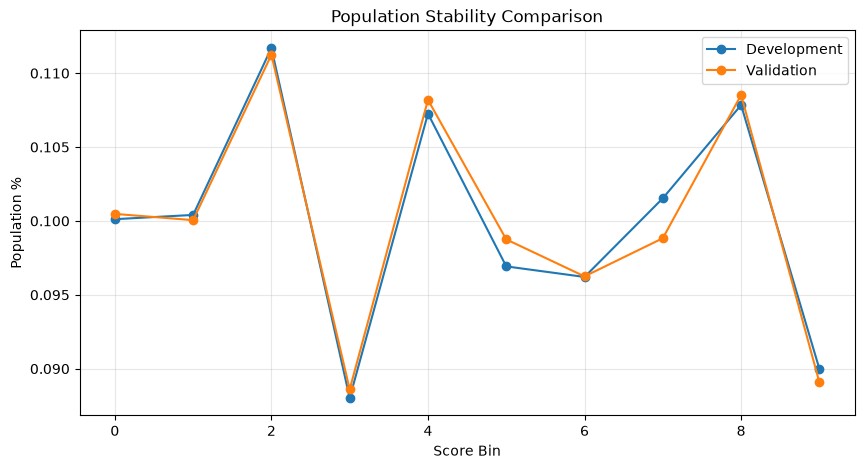

In [34]:
plt.figure(figsize=(10,5))

plt.plot(
    psi_df['Development'],
    marker='o',
    label='Development'
)

plt.plot(
    psi_df['Validation'],
    marker='o',
    label='Validation'
)

plt.title("Population Stability Comparison")

plt.xlabel("Score Bin")

plt.ylabel("Population %")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [35]:
psi_df.to_csv(
    "../Reports/psi_summary.csv",
    index=False
)

In [36]:
psi_summary = pd.DataFrame({

    'Metric': ['PSI'],

    'Value': [total_psi],

    'Interpretation': [interpretation]

})

psi_summary.to_csv(
    "../Reports/psi_result.csv",
    index=False
)

psi_summary

,Metric,Value,Interpretation
0,PSI,0.000137,Stable Population


In [37]:
calibration.to_csv("../Reports/calibration_summary.csv", index=False)
lift_table.to_csv("../Reports/lift_summary.csv")
psi_df.to_csv("../Reports/psi_summary.csv", index=False)
portfolio_seg.to_csv("../Reports/grade_summary.csv", index=False)

### Interpretation

The Population Stability Index (PSI) between the development and validation populations is **0.000137**, which is substantially below the industry threshold of **0.10**.

This indicates:

- No measurable population drift.
- Nearly identical score distributions across train and test datasets.
- Stable model behaviour on the validation population.
- Reliable out-of-sample model evaluation.

The overlapping score distributions further confirm that the validation sample is representative of the development population.

### CSI Report

In [38]:
def calculate_csi(dev, val, bins=10):
    """
    Calculate Characteristic Stability Index (CSI)
    """

    # Create bins using development data
    breakpoints = np.unique(
        np.percentile(
            dev,
            np.linspace(0, 100, bins + 1)
        )
    )

    # Assign bins
    dev_bins = pd.cut(
        dev,
        bins=breakpoints,
        include_lowest=True
    )

    val_bins = pd.cut(
        val,
        bins=breakpoints,
        include_lowest=True
    )

    # Distribution
    dev_pct = (
        dev_bins.value_counts(normalize=True)
        .sort_index()
    )

    val_pct = (
        val_bins.value_counts(normalize=True)
        .sort_index()
    )

    # Avoid divide-by-zero
    dev_pct = dev_pct.replace(0, 0.0001)
    val_pct = val_pct.replace(0, 0.0001)

    # CSI
    csi = (
        (val_pct - dev_pct)
        *
        np.log(val_pct / dev_pct)
    ).sum()

    return csi

In [39]:
csi_results = []

for feature in final_features:

    csi = calculate_csi(
        train_model[feature],
        test_model[feature]
    )

    csi_results.append({
        "Feature": feature,
        "CSI": csi
    })

csi_df = pd.DataFrame(csi_results)

In [40]:
def interpret_csi(value):

    if value < 0.10:
        return "Stable"

    elif value < 0.25:
        return "Moderate Shift"

    else:
        return "Significant Shift"


csi_df["Interpretation"] = (
    csi_df["CSI"]
    .apply(interpret_csi)
)

csi_df = (
    csi_df
    .sort_values(
        "CSI",
        ascending=False
    )
    .reset_index(drop=True)
)

csi_df

,Feature,CSI,Interpretation
0,avg_credit_age_years_woe,0.000123,Stable
1,num_approved_woe,0.000048,Stable
2,age_years_woe,0.000015,Stable
3,avg_instalment_remaining_woe,0.000012,Stable
4,avg_credit_grant_ratio_woe,0.000005,Stable
5,num_refused_woe,0.000002,Stable


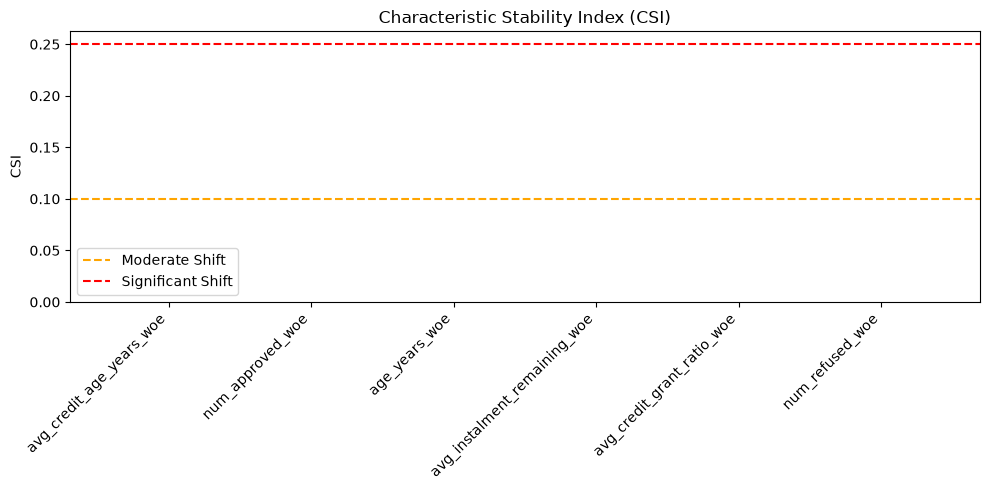

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    csi_df["Feature"],
    csi_df["CSI"]
)

plt.axhline(
    0.10,
    color='orange',
    linestyle='--',
    label='Moderate Shift'
)

plt.axhline(
    0.25,
    color='red',
    linestyle='--',
    label='Significant Shift'
)

plt.xticks(rotation=45, ha='right')

plt.ylabel("CSI")

plt.title("Characteristic Stability Index (CSI)")

plt.legend()

plt.tight_layout()

plt.show()

In [42]:
csi_df.to_csv(
    "../Reports/csi_summary.csv",
    index=False
)

### Interpretation

The Characteristic Stability Index (CSI) was calculated for all final model predictors to assess whether any individual characteristic exhibited distributional drift between the development and validation populations.

All variables recorded CSI values well below the industry threshold of **0.10**, indicating excellent characteristic stability.

This result is expected because the validation sample was obtained through a random train-test split of the same portfolio, resulting in highly similar predictor distributions. Consequently, there is no evidence of characteristic drift that would require model recalibration or redevelopment.